In [1]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset
from transformers import AutoFeatureExtractor
from transformers import WavLMForSequenceClassification, Trainer, TrainingArguments
import evaluate
import numpy as np
from sklearn.metrics import classification_report

# --------------------
# Dataset definition
# --------------------
class WavLMDataset(Dataset):
    def __init__(self, root_dir, feature_extractor, target_sr=16000, max_duration=10.0):
        self.files = []
        self.labels = []
        self.feature_extractor = feature_extractor
        self.target_sr = target_sr
        self.max_length = int(target_sr * max_duration)

        for fname in os.listdir(root_dir):
            if fname.lower().endswith(".wav"):
                path = os.path.join(root_dir, fname)
                label = 0 if fname.lower().startswith("real_") else 1
                self.files.append(path)
                self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        label = self.labels[idx]

        waveform, sr = torchaudio.load(path)

        # Convert to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Resample if needed
        if sr != self.target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, self.target_sr)

        waveform = waveform.squeeze().numpy()

        # Pad or truncate to fixed length
        if len(waveform) > self.max_length:
            waveform = waveform[:self.max_length]
        else:
            pad = self.max_length - len(waveform)
            waveform = np.pad(waveform, (0, pad), mode="constant")

        # Use feature extractor
        inputs = self.feature_extractor(
            waveform,
            sampling_rate=self.target_sr,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs["labels"] = torch.tensor(label, dtype=torch.long)
        return inputs


# --------------------
# Load feature extractor & model
# --------------------
checkpoint = "microsoft/wavlm-base"
feature_extractor = AutoFeatureExtractor.from_pretrained(checkpoint)

model = WavLMForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2
)

# --------------------
# Create datasets
# --------------------
train_dataset = WavLMDataset(r"D:\Thesis\Song\dataset\Train", feature_extractor)
valid_dataset = WavLMDataset(r"D:\Thesis\Song\dataset\Valid", feature_extractor)
test_dataset  = WavLMDataset(r"D:\Thesis\Song\dataset\Test", feature_extractor)

# --------------------
# Metrics
# --------------------
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

# --------------------
# Training - COMPATIBLE WITH OLDER VERSIONS
# --------------------
training_args = TrainingArguments(
    output_dir="./wavlm-finetuned",
    eval_strategy="epoch",  # ✅ Evaluate at the end of each epoch
    save_strategy="epoch",   # ✅ Save at the end of each epoch
    # save_steps=500,   # Save every 500 steps
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",  # Use "eval_f1" instead of "f1"
    greater_is_better=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics
)

print("Starting training with WavLM...")
trainer.train()

# --------------------
# Evaluation on test set
# --------------------
print("Evaluating on test set...")
metrics = trainer.evaluate(test_dataset)
print(metrics)

# Get predictions for classification report
predictions = trainer.predict(test_dataset)
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

report = classification_report(
    y_true, y_pred,
    target_names=["Real", "AI-Generated"],
    digits=4
)
print(report)

# --------------------
# Save results to file
# --------------------
output_path = "./wavlm-finetuned/evaluation_results.txt"
with open(output_path, "w") as f:
    f.write("==== Test Metrics ====\n")
    for k, v in metrics.items():
        f.write(f"{k}: {v:.4f}\n")

    f.write("\n==== Classification Report ====\n")
    f.write(report)

print(f"Saved evaluation results to {output_path}")

# Optional: Save the fine-tuned model
model.save_pretrained("./wavlm-finetuned/final-model")
feature_extractor.save_pretrained("./wavlm-finetuned/final-model")
print("Model saved to ./wavlm-finetuned/final-model/")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Some weights of WavLMForSequenceClassification were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\j3n50\AppData\Local\Temp\ipykernel_30396\1867801925.py:122: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Starting training with WavLM...


c:\Users\j3n50\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.263900,0.429557,0.901167,0.898708
2,0.119100,0.199067,0.962938,0.962721
3,0.050100,0.199975,0.967056,0.966787


...

Evaluating on test set...


c:\Users\j3n50\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


{'eval_loss': 0.2332877665758133, 'eval_accuracy': 0.9627473806752037, 'eval_f1': 0.9625708061002178, 'eval_runtime': 65.5886, 'eval_samples_per_second': 26.194, 'eval_steps_per_second': 6.556, 'epoch': 3.0}


c:\Users\j3n50\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


              precision    recall  f1-score   support

        Real     0.9630    0.9672    0.9651       916
AI-Generated     0.9624    0.9576    0.9600       802

    accuracy                         0.9627      1718
   macro avg     0.9627    0.9624    0.9626      1718
weighted avg     0.9627    0.9627    0.9627      1718

Saved evaluation results to ./wavlm-finetuned/evaluation_results.txt
Model saved to ./wavlm-finetuned/final-model/


In [3]:
import transformers
print("Transformers version:", transformers.__version__)

Transformers version: 4.56.1


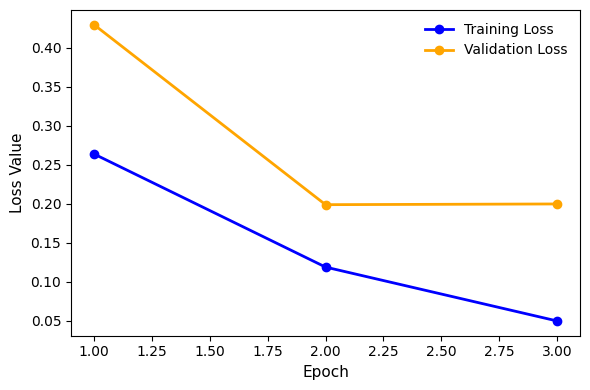

In [2]:
import matplotlib.pyplot as plt

# Data
epochs = [1, 2, 3]
train_loss = [0.263900, 0.119100, 0.050100]
val_loss = [0.429557, 0.199067, 0.199975]

# Create clean plot
plt.figure(figsize=(6, 4))

# Plot training and validation loss (with bullet points)
plt.plot(epochs, train_loss, color='blue', marker='o', markersize=6, linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, color='orange', marker='o', markersize=6, linewidth=2, label='Validation Loss')

# Labels
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Loss Value', fontsize=11)

# Clean white background and no grid
plt.grid(False)
plt.gca().set_facecolor('white')
plt.box(True)

# Legend
plt.legend(frameon=False, fontsize=10, loc='best')

# Final layout
plt.tight_layout()
plt.show()
